# **Atividade Prática**
<font size=3>

- **Tema:** problema das 8 rainhas.
- **Prazo de entrega:** 22 de Setembro.
---

## **Enunciado:**
<font size=3>
    
O **problema das 8 rainhas** é um quebra-cabeça clássico e um exemplo canônico em ciência da computação e inteligência artificial. O desafio é simples de enunciar, mas complexo de resolver: posicionar 8 rainhas de xadrez em um tabuleiro 8x8 de tal forma que nenhuma rainha possa atacar qualquer outra. Isso significa que não pode haver duas rainhas na mesma linha, na mesma coluna ou na mesma diagonal.

Para resolver este problema computacionalmente, representamos o tabuleiro inteiro com uma única **lista (ou vetor) de 8 posições**:

* O **índice** da lista (0 a 7) corresponde à **coluna** do tabuleiro.

* O **valor** armazenado nesse índice (0 a 7) corresponde à **linha** onde a rainha daquela coluna está posicionada.


<font size=3>

**Exemplo simplificado:**

Vamos imaginar um mini-tabuleiro 4x4 para facilitar a visualização. Um estado representado pela lista `[1, 3, 0, 2]` seria interpretado assim:

  * `estado[0] = 1` ➔ Na **coluna 0**, a rainha está na **linha 1**.
  * `estado[1] = 3` ➔ Na **coluna 1**, a rainha está na **linha 3**.
  * `estado[2] = 0` ➔ Na **coluna 2**, a rainha está na **linha 0**.
  * `estado[3] = 2` ➔ Na **coluna 3**, a rainha está na **linha 2**.

Visualmente, o tabuleiro ficaria assim:

<font size=2.5>
    
```
    (colunas)
    
   0  1  2  3
  +--+--+--+--+
0 |  |  | Q|  |  (linha 0)
  +--+--+--+--+
1 | Q|  |  |  |  (linha 1)
  +--+--+--+--+
2 |  |  |  | Q|  (linha 2)
  +--+--+--+--+
3 |  | Q|  |  |  (linha 3)
  +--+--+--+--+


```

---

### **1. Questão: busca por escalada**
<font size=3>

- **1.1 Pergunta teórica:** em uma célula **markdown**, descreva por que o algoritmo de **Busca por Escalada** é considerado um exemplo de **busca local**.
  
- **1.2 Implementação:** com base na implementação do algoritmo `HillClimbingSearch` do **_Notebook_ 4**:
  - Termine a implementação da classe `EightQueensProblem` abaixo, com base nas dicas de cada método;
  - Declare uma variável para ser o **estado inicial** do tabuleiro, utilizando o atributo `initial_state` do objeto de `EightQueensProblem`;
  - O **estado final** do tabulerio deve ser encontrado ao realizar a busca do modelo definido;
  - Plot o resultado com a função `plot_result` do pacote `ativ4.py` (**importe o pacote**), ela irá receber os estados **inicial** e **final** do tabuleiro;
  - Verifique se a **solução** foi encontrada.

> **Observação:** faz parte da atividade o(a) estudante investigar as funções e classes contidas em `ativ4.py` e utilizá-las **corretamente**, além de importar qualquer outra biblioteca necessária para cumprir o que se pede na atividade.


### Busca por Escalada (Hill-Climbing Search)

De acordo com Russel (2010) em Artificial Intelligence - A Modern Approach, na seção 4.1.1, a Busca por Escalada ou Hill-Climbing Search, às vezes é chamada de busca local ou busca local gulosa, por selecionar um estado vizinho favorável sem realizar um planejamento prévio para os próximos passos.

Entretanto, apesar de apresentar um desempenho considerável ainda pode ficar travada, seja por um máximo local, sequência de *cumes* (Ridges) ou mesmo pelos planaltos (Russel, 2010), pois pode não encontrar um vizinho próximo que seja favorável e, com isso, pode acabar se "perdendo" nessas áreas citadas. 

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive/')

In [3]:
import numpy as np
import ativ4

In [4]:
class EightQueensProblem(ativ4.Problem):
    
    def __init__(self, n = 8):
        self.n = n
        initial_state = list(np.random.randint(0, n, size = n))
        
        super().__init__(initial_state = initial_state,
                         actions = self.get_actions,
                         transition_model = self.apply_action)
        
        # A função de valor que queremos maximizar é o número de pares sem ataques:
        self.value_function = self.calculate_non_attacking_pairs

    def calculate_non_attacking_pairs(self, state):
        """Calcula o número de pares de rainhas que não se atacam."""
        
        maxpares = (self.n*(self.n - 1))/2
        conflitos = 0
        for col1 in range(self.n):
            for col2 in range(col1 + 1, self.n):
                if state[col1] == state[col2]:
                    conflitos = conflitos + 1
                if abs(state[col1] - state[col2]) == abs(col1 - col2):
                    conflitos = conflitos + 1    

        return maxpares - conflitos

    def get_actions(self, state):
        """Gera todas as ações possíveis."""

        actions = []
        for col in range(self.n):
            linha_atual = state[col]
            for nova_linha in range(self.n):
                if nova_linha != linha_atual:
                    actions.append((col, nova_linha))
        return actions    
        
    def apply_action(self, state, action):
        """Aplica uma ação para gerar um novo estado."""

        col, nova_linha = action
        nova_lista = list(state)
        nova_lista[col] = nova_linha
        return nova_lista  

In [1]:
class HillClimbingSearch:

    def __init__(self, problem):
        self.problem = problem

    def search(self):
        """Executa a busca por escalada e retorna o estado de máximo local."""

        current_node = ativ4.Node(self.problem.initial_state)

        while True:
            neighbors = [ativ4.Node(self.problem.transition_model(current_node.state, action))
                          for action in self.problem.actions(current_node.state)]

            if not neighbors:
                break

            best_neighbor = max(neighbors, key = lambda node: self.problem.value_function(node.state))

            neighbor_value = self.problem.value_function(best_neighbor.state)
            current_value = self.problem.value_function(current_node.state)

            if neighbor_value <= current_value:
                return current_node.state

            current_node = best_neighbor

        return current_node.state


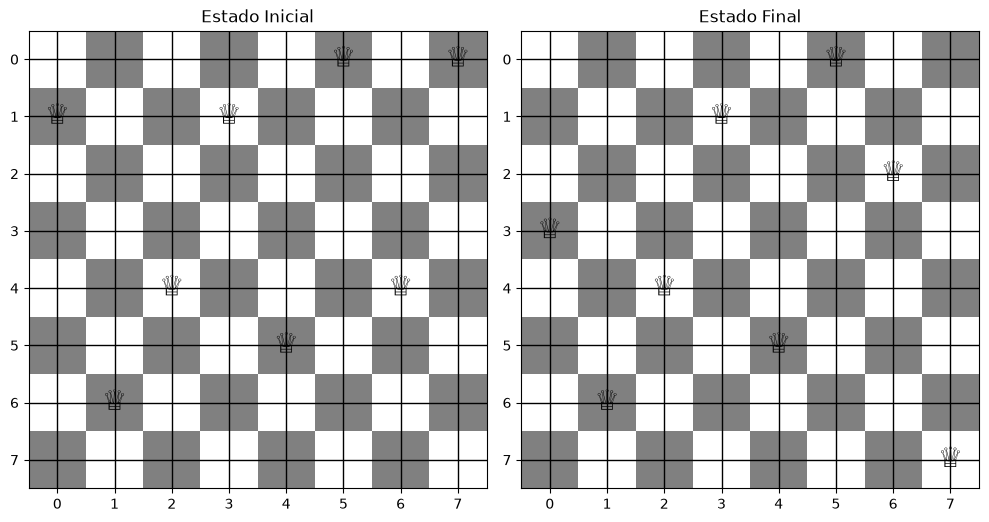

In [38]:
problema = EightQueensProblem()
busca_escalada = HillClimbingSearch(problema)
solucao = busca_escalada.search()

ativ4.plot_result(solucao, problema.initial_state)

### Checagem da solução encontrada
Como o Hill-Climbing Search pode ficar preso em um máximo local, o resultado em que há conflitos pode ser representativo de um máximo local. Para chegar em um máximo global (solução ideal) basta reexecutar algumas vezes até ser alcançado esse estado ideal.

---

### **2. Questão: busca por recozimento simulado**
<font size=3>

- **2.1 Pergunta teórica:** em uma célula **markdown**, descreva por que o algoritmo de **Busca por Recozimento Simulado** pode ser considerado robusto quando comparado à **Busca por Escalada**.
  
- **2.2 Implementação:** com base na implementação do algoritmo `SimulatedAnnealingSearch` do **_Notebook_ 4**:
  - Defina o **estado final** do tabulerio realizando a busca com modelo definido. Reutilize o *objeto* do problema da **questão 1** para declarar o modelo;
  - Plot o resultado com a função `plot_result` de `ativ4.py`, ela irá receber os estados **inicial** (definido na **questão 1**) e **final** do tabuleiro;
  - Verifique se a **solução** foi encontrada.


### Recozimento Simulado (Simulated Annealing)

Segundo o material: [4 - Buscas em ambientes complexos - 1.2](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=c7cb5a9d-5eac-402f-bee9-ab5861708dfd) disponibilizado pelo Prof. Dr. Tibério Pereira, o algoritmo de Busca por Recozimento Simulado pode ser considerado robusto, em comparação à Busca por Escalada, por permitir movimentos para estados piores com uma certa probabilidade. Dessa forma, essa característica acaba evitando que o algoritmo fique preso em máximos locais e aumenta a chance de encontrar o ótimo global.

In [1]:
class SimulatedAnnealingSearch:

    def __init__(self, problem, schedule):
        self.problem = problem
        self.schedule = schedule

    def search(self, max_iterations = 5000):

        current_node = ativ4.Node(self.problem.initial_state)
        best_node = current_node

        for t in range(1, max_iterations):
            T = self.schedule(t) 

            if T < 1e-4: 
                return best_node.state

            actions = self.problem.actions(current_node.state)
            if not actions: break

            random_action = actions[np.random.randint(0, len(actions))]
            next_node = ativ4.Node(self.problem.transition_model(current_node.state, random_action))

            ΔE = self.problem.value_function(next_node.state) - self.problem.value_function(current_node.state)

            if ΔE > 0: 
                current_node = next_node

                if self.problem.value_function(current_node.state) > self.problem.value_function(best_node.state):
                    best_node = current_node

            else: # caso ΔE <= 0:
                probability = np.exp(ΔE/T) 
                                           
                if np.random.rand() < probability:
                    current_node = next_node

        return best_node.state

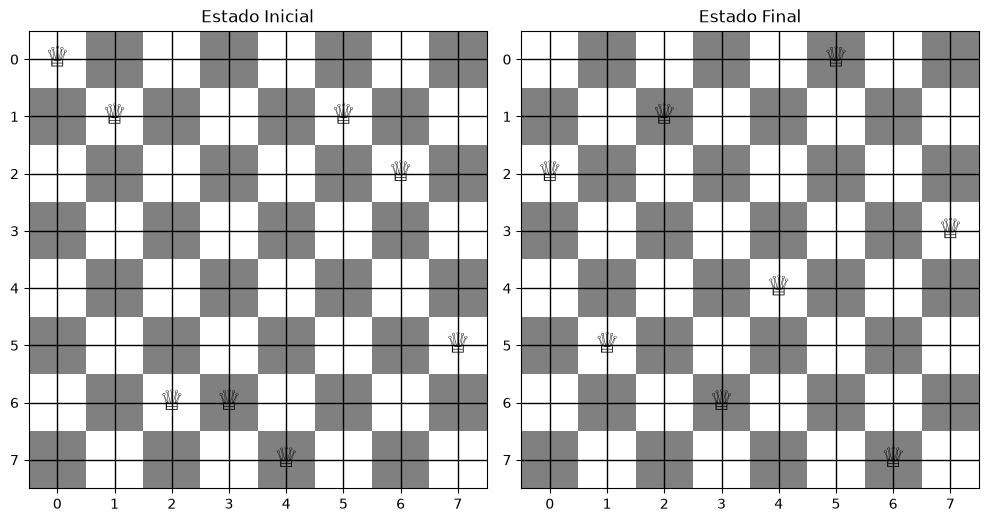

In [10]:
problema = EightQueensProblem()

def exponential_schedule(t, temp_initial = 50.0, alpha = 0.995):
    return temp_initial*(alpha**t)

busca_recozimento = SimulatedAnnealingSearch(problema, exponential_schedule)
solucao1 = busca_recozimento.search()

ativ4.plot_result(solucao1, problema.initial_state)

### Checagem da solução encontrada

Como esperado, o uso do Recozimento Simulado (Simulated Annealing) acaba trazendo uma solução ótima com mais facilidade do que o Hill-Climbing Search, especialmente por ter essa otimização de permitir ir para estados piores mesmo estando em um máximo local. Porém, como destacado no material [4 - Buscas em ambientes complexos - 1.2](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=c7cb5a9d-5eac-402f-bee9-ab5861708dfd) é necessário estar atento à *função de resfriamento*, que pode comprometer o desempenho do método, pois quanto mais lento o resfriamento, mais tempo o algoritmo poderá levar para chegar na solução, ou seja, é importante se atentar, em particular, ao valor do *alpha* dado na função.

---

### **3. Questão: algoritmo genético**
<font size=3>

- **3.1 Pergunta teórica:** em uma célula **markdown**, descreva as características do **Algoritmo Genético** que se assemelham ao algoritmo de **Busca por Recozimento Simulado**.
  
- **3.2 Implementação:** com base na implementação do algoritmo `GeneticAlgorithmSeach` do **_Notebook_ 4**:
  - Termine a implementação da classe `EightQueensGAProblem` abaixo, com base nas dicas de cada método — problema adaptado para o algoritmo genético;
  - Defina o **estado final** do tabulerio realizando a busca com modelo definido;
  - Plot o resultado com a função `plot_result` de `ativ4.py`. Como o "estado inicial", para este algoritmo, na verdade é uma **população de estados**, vamos considerar o plot apenas do **estado final** do tabuleiro;
  - Verifique se a **solução** foi encontrada.
    

In [ ]:
class EightQueensGAProblem:

    def __init__(self, n=8):
        self.n = n
        
        # DICA:
        # - O valor perfeito de aptidão (fitness) é o número total de pares sem conflito.
        # - Para 'n' rainhas, o número máximo de pares é dado por: (n*(n - 1))/2.
        self.perfect_score = (n*(n - 1))/2

    def initialize_individual(self):
        """Cria um indivíduo (tabuleiro) aleatório."""
        
        # DICA:
        # - Um indivíduo é uma lista de tamanho 'n', onde o índice representa a coluna 
        #   e o valor representa a linha da rainha (ex: [3, 0, 4, 1, ...]);
        # - Crie um vetor com 'n' inteiros aleatórios no intervalo de 0 a n-1;
        # - Dica de código: utilize `np.random.randint(0, self.n, self.n).tolist()`.
        
        raise NotImplementedError

    def fitness(self, individual):
        """Calcula a aptidão do indivíduo (quantidade de pares não-atacantes)."""
        
        # DICA:
        # - A variável `individual` é uma lista com as linhas de cada rainha;
        # - Itere sobre todos os pares de colunas (col1 e col2, onde col2 > col1);
        # - Incremente o contador de ataques se as rainhas estiverem na mesma linha:
        #   `individual[col1] == individual[col2]`
        #   ou na mesma diagonal:
        #   `abs(individual[col1] - individual[col2]) == abs(col1 - col2)`;
        # - Retorne o total ideal menos os pares atacantes (`self.perfect_score - pares_atacantes`).
        
        raise NotImplementedError

    def reproduce(self, parent1, parent2, crossover_rate):
        """Realiza o crossover de ponto único entre dois indivíduos pais."""
        
        # DICA:
        # - Gere um número aleatório entre 0 e 1 (ex: `np.random.rand()`);
        # - Se o valor for maior que `crossover_rate`, não ocorre crossover: 
        #   retorne cópias exatas dos pais (`parent1[:]`, `parent2[:]`);
        # - Caso contrário, escolha um ponto de corte `c` entre 1 e n-1 (`np.random.randint(1, self.n)`);
        # - Crie o filho 1 combinando: `parent1[:c] + parent2[c:]`;
        # - Crie o filho 2 combinando: `parent2[:c] + parent1[c:]`;
        # - Retorne os dois filhos gerados.
        
        raise NotImplementedError

    def mutate(self, individual, mutation_rate):
        """Altera a posição da rainha em uma coluna aleatória segundo a taxa de mutação."""
        
        # DICA:
        # - Avalie a probabilidade de mutação (`if np.random.rand() < mutation_rate:`):
        #   1. Sorteie uma coluna aleatória (`col = np.random.randint(self.n)`);
        #   2. Atribua uma nova linha aleatória para essa coluna (`individual[col] = np.random.randint(self.n)`);
        # - Retorne o indivíduo (alterado ou inalterado).
        
        raise NotImplementedError

    def is_solution(self, fitness):
        """Verifica se o indivíduo atingiu a pontuação máxima (solução perfeita)."""
        
        # DICA:
        # - Retorne uma expressão booleana comparando se `fitness == self.perfect_score`.
        
        raise NotImplementedError

